# 04 — Analysis & Visualisation

Goes beyond the numbers to tell the story of what our xG model reveals:

1. **xG across leagues** — Does a single model generalise? Which leagues are hardest to score in?
2. **Men's vs Women's football** — Structural differences in chance creation and conversion
3. **League-specific models** — Would dedicated models outperform the universal one?
4. **Competition difficulty** — Where do the hardest and easiest chances come from?
5. **Player over/underperformers** — Who beats their xG?
6. **Match-level xG timelines** — Famous matches through the lens of xG

In [1]:
import sys, os
sys.path.insert(0, "..")
os.chdir("..")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
from mplsoccer import VerticalPitch, Pitch

from src.features.build_features import FEATURE_COLUMNS, TARGET
from src.evaluation.evaluate import load_models, predict

sns.set_theme(style="whitegrid")

df = pd.read_parquet("data/processed/features.parquet")
models = load_models()
xgb = models["xgboost"]

# Add XGBoost predictions to all data
df["xg_pred"] = predict(xgb, df, FEATURE_COLUMNS)

# Classify men's vs women's
WOMENS = {"FA Women's Super League", "NWSL", "Women's World Cup", "UEFA Women's Euro"}
df["gender"] = df["competition"].apply(lambda c: "Women" if c in WOMENS else "Men")

print(f"Total shots: {len(df):,}")
print(f"Men: {(df.gender=='Men').sum():,} | Women: {(df.gender=='Women').sum():,}")

Total shots: 88,023
Men: 73,874 | Women: 14,149


---
## 1. Does the model generalise across leagues?

We trained on all competitions jointly. How well does it calibrate for each one individually?

In [2]:
# Per-competition metrics (only competitions with enough data)
min_shots = 500
comp_metrics = []

for comp, group in df.groupby("competition"):
    if len(group) < min_shots:
        continue
    y_true = group["is_goal"].values
    y_pred = group["xg_pred"].values
    y_sb = group["shot_statsbomb_xg"].values
    
    comp_metrics.append({
        "competition": comp,
        "gender": group["gender"].iloc[0],
        "shots": len(group),
        "goal_rate": y_true.mean(),
        "our_log_loss": log_loss(y_true, y_pred),
        "sb_log_loss": log_loss(y_true, y_sb),
        "our_brier": brier_score_loss(y_true, y_pred),
        "sb_brier": brier_score_loss(y_true, y_sb),
        "our_auc": roc_auc_score(y_true, y_pred),
        "sb_auc": roc_auc_score(y_true, y_sb),
    })

cm = pd.DataFrame(comp_metrics).sort_values("shots", ascending=False)
print(cm[["competition", "gender", "shots", "goal_rate", "our_log_loss", "sb_log_loss", "our_auc", "sb_auc"]].to_string(index=False))

            competition gender  shots  goal_rate  our_log_loss  sb_log_loss  our_auc   sb_auc
                La Liga    Men  21210   0.125318      0.260198     0.288639 0.865637 0.826070
         Premier League    Men  10837   0.099843      0.228060     0.251308 0.859867 0.816265
                Ligue 1    Men  10346   0.106805      0.235537     0.263508 0.867582 0.819826
                Serie A    Men  10033   0.095186      0.212511     0.233849 0.881239 0.841387
          1. Bundesliga    Men   8747   0.108266      0.232879     0.254547 0.870947 0.837206
FA Women's Super League  Women   8321   0.115611      0.258871     0.296380 0.850285 0.785565
         FIFA World Cup    Men   3904   0.113473      0.239557     0.258849 0.869053 0.839262
    Indian Super league    Men   3095   0.111470      0.258025     0.294216 0.843306 0.775504
      Women's World Cup  Women   2994   0.109218      0.231607     0.254208 0.860906 0.840216
              UEFA Euro    Men   2629   0.106885      0.2447

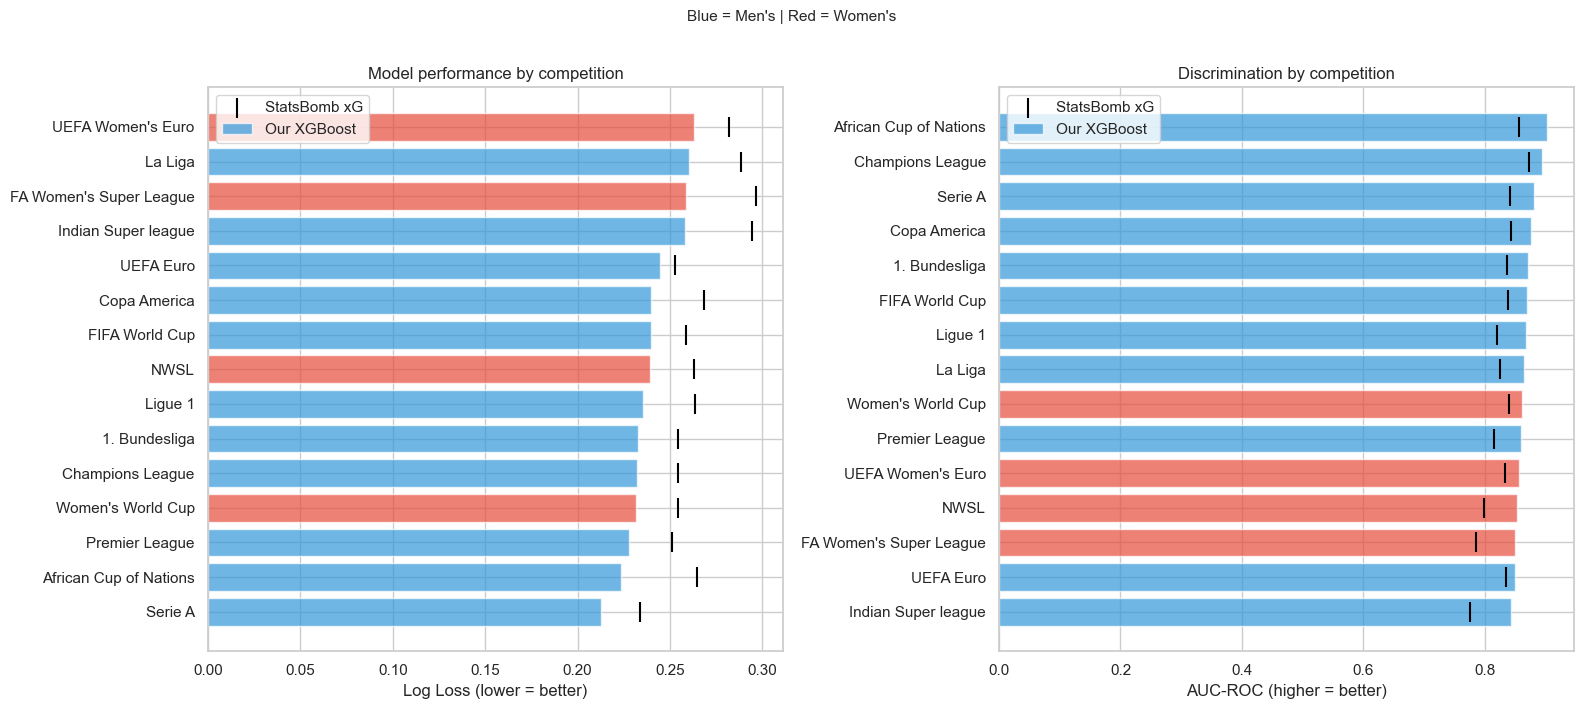

In [3]:
# Visualise: our model vs StatsBomb by competition
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cm_sorted = cm.sort_values("our_log_loss")
colors = ["#e74c3c" if g == "Women" else "#3498db" for g in cm_sorted["gender"]]

# Log loss comparison
y_pos = range(len(cm_sorted))
axes[0].barh(y_pos, cm_sorted["our_log_loss"], color=colors, alpha=0.7, label="Our XGBoost")
axes[0].scatter(cm_sorted["sb_log_loss"], y_pos, color="black", marker="|", s=200, zorder=5, label="StatsBomb xG")
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(cm_sorted["competition"])
axes[0].set_xlabel("Log Loss (lower = better)")
axes[0].set_title("Model performance by competition")
axes[0].legend()

# AUC comparison
cm_sorted2 = cm.sort_values("our_auc")
colors2 = ["#e74c3c" if g == "Women" else "#3498db" for g in cm_sorted2["gender"]]
axes[1].barh(range(len(cm_sorted2)), cm_sorted2["our_auc"], color=colors2, alpha=0.7, label="Our XGBoost")
axes[1].scatter(cm_sorted2["sb_auc"], range(len(cm_sorted2)), color="black", marker="|", s=200, zorder=5, label="StatsBomb xG")
axes[1].set_yticks(range(len(cm_sorted2)))
axes[1].set_yticklabels(cm_sorted2["competition"])
axes[1].set_xlabel("AUC-ROC (higher = better)")
axes[1].set_title("Discrimination by competition")
axes[1].legend()

plt.suptitle("Blue = Men's | Red = Women's", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

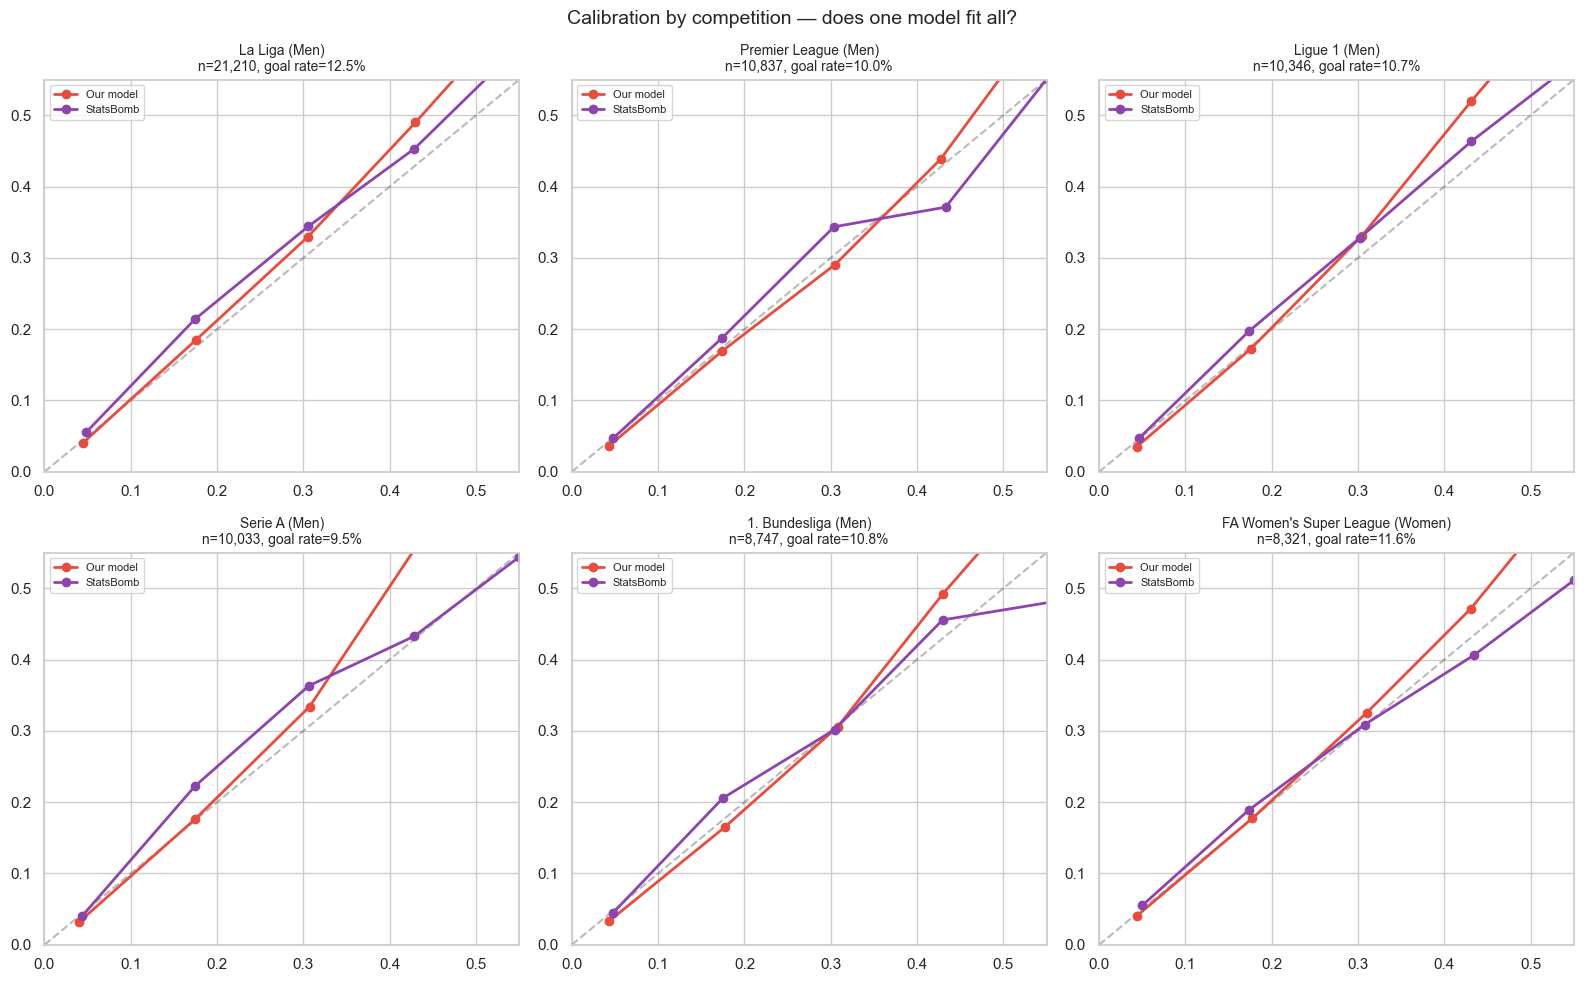

In [4]:
# Calibration curves per competition (top 6 by volume)
top_comps = cm.nlargest(6, "shots")["competition"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, comp in zip(axes.flat, top_comps):
    group = df[df["competition"] == comp]
    y_true = group["is_goal"].values
    
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    
    for label, preds, color in [
        ("Our model", group["xg_pred"].values, "#e74c3c"),
        ("StatsBomb", group["shot_statsbomb_xg"].values, "#8e44ad"),
    ]:
        prob_true, prob_pred = calibration_curve(y_true, preds, n_bins=8, strategy="uniform")
        ax.plot(prob_pred, prob_true, marker="o", label=label, color=color, linewidth=2)
    
    gender = group["gender"].iloc[0]
    ax.set_title(f"{comp} ({gender})\nn={len(group):,}, goal rate={y_true.mean():.1%}", fontsize=10)
    ax.set_xlim(0, 0.55)
    ax.set_ylim(0, 0.55)
    ax.legend(fontsize=8)

plt.suptitle("Calibration by competition — does one model fit all?", fontsize=14)
plt.tight_layout()
plt.show()

---
## 2. Men's vs Women's football

Are there structural differences in how chances are created and converted?

In [5]:
# Compare key features between men's and women's
gender_stats = df.groupby("gender").agg(
    shots=("is_goal", "count"),
    goal_rate=("is_goal", "mean"),
    mean_distance=("distance_to_goal", "mean"),
    mean_angle=("angle_to_goal", lambda x: np.degrees(x).mean()),
    mean_defenders=("n_defenders_in_cone", "mean"),
    header_pct=("is_header", "mean"),
    first_time_pct=("is_first_time", "mean"),
    one_on_one_pct=("is_one_on_one", "mean"),
    counter_pct=("is_counter_attack", "mean"),
    mean_xg_pred=("xg_pred", "mean"),
    mean_sb_xg=("shot_statsbomb_xg", "mean"),
)
print(gender_stats.T.to_string())

gender                   Men         Women
shots           73874.000000  14149.000000
goal_rate           0.110797      0.113436
mean_distance      19.358396     18.251573
mean_angle         25.021758     27.473276
mean_defenders      1.714527      1.825359
header_pct          0.156808      0.168210
first_time_pct      0.307700      0.276981
one_on_one_pct      0.054133      0.046788
counter_pct         0.044183      0.050534
mean_xg_pred        0.110995      0.116083
mean_sb_xg          0.105269      0.113543


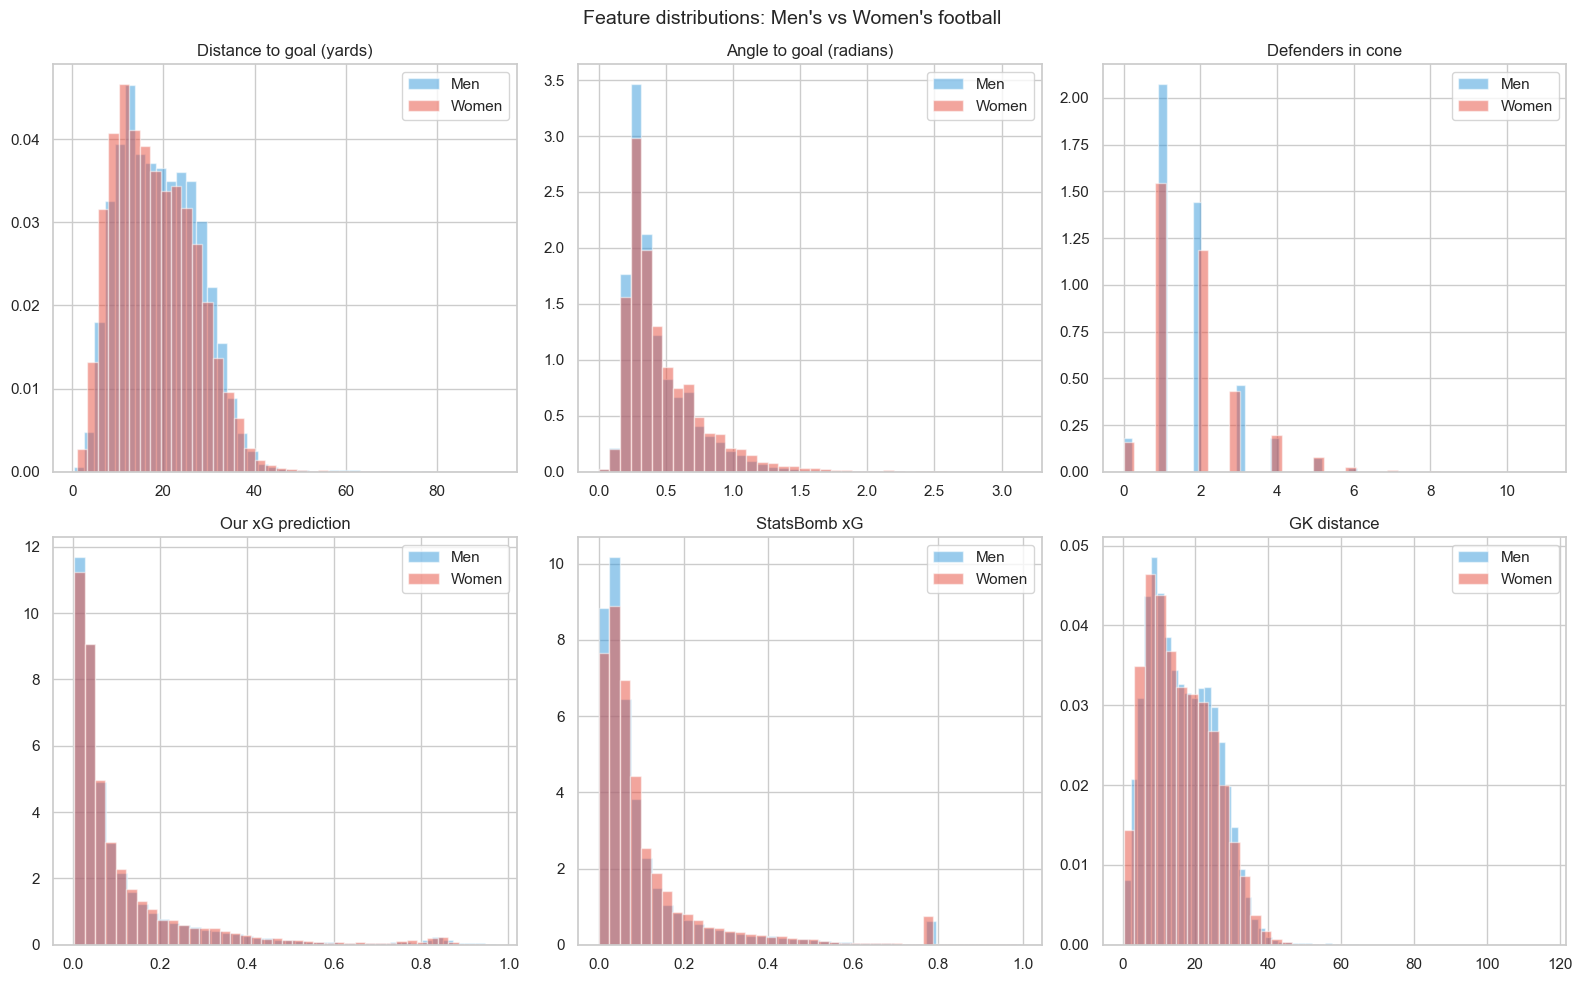

In [6]:
# Feature distributions: men's vs women's
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features_to_compare = [
    ("distance_to_goal", "Distance to goal (yards)"),
    ("angle_to_goal", "Angle to goal (radians)"),
    ("n_defenders_in_cone", "Defenders in cone"),
    ("xg_pred", "Our xG prediction"),
    ("shot_statsbomb_xg", "StatsBomb xG"),
    ("gk_distance", "GK distance"),
]

for ax, (feat, title) in zip(axes.flat, features_to_compare):
    for gender, color in [("Men", "#3498db"), ("Women", "#e74c3c")]:
        vals = df.loc[df["gender"] == gender, feat].dropna()
        ax.hist(vals, bins=40, alpha=0.5, density=True, color=color, label=gender)
    ax.set_title(title)
    ax.legend()

plt.suptitle("Feature distributions: Men's vs Women's football", fontsize=14)
plt.tight_layout()
plt.show()

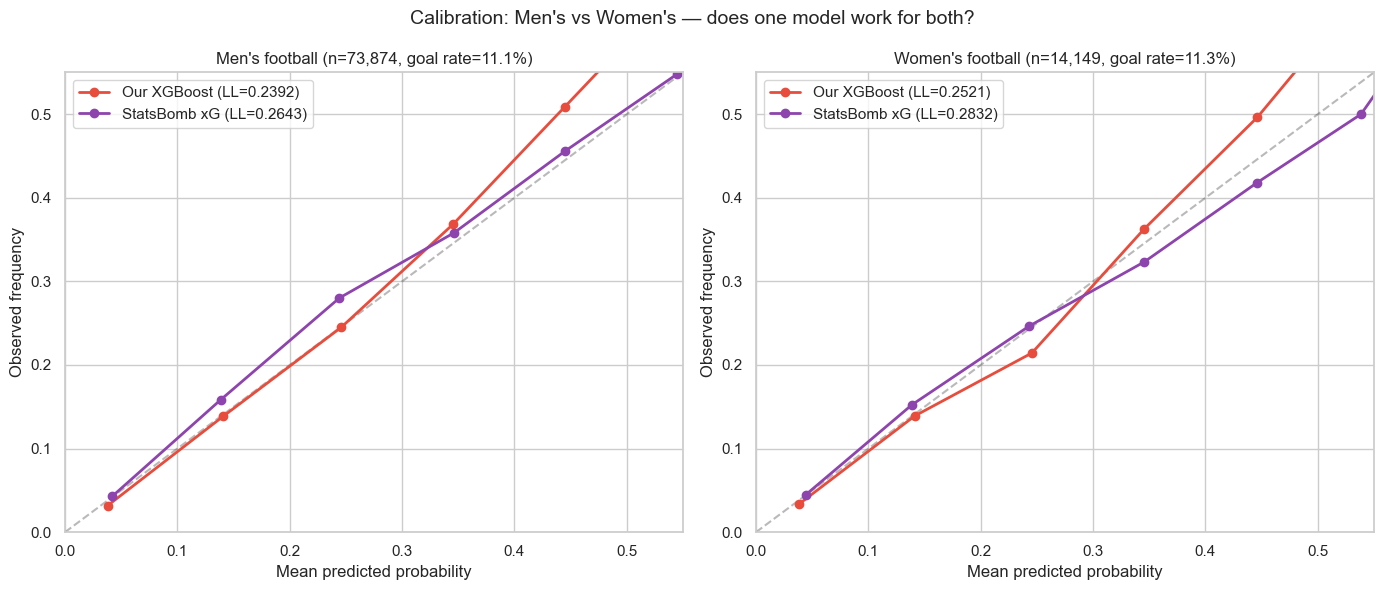

In [7]:
# Calibration split by gender
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, gender in zip(axes, ["Men", "Women"]):
    group = df[df["gender"] == gender]
    y_true = group["is_goal"].values
    
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    
    for label, preds, color in [
        ("Our XGBoost", group["xg_pred"].values, "#e74c3c"),
        ("StatsBomb xG", group["shot_statsbomb_xg"].values, "#8e44ad"),
    ]:
        prob_true, prob_pred = calibration_curve(y_true, preds, n_bins=10, strategy="uniform")
        ll = log_loss(y_true, preds)
        ax.plot(prob_pred, prob_true, marker="o", label=f"{label} (LL={ll:.4f})", color=color, linewidth=2)
    
    ax.set_title(f"{gender}'s football (n={len(group):,}, goal rate={y_true.mean():.1%})", fontsize=12)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_xlim(0, 0.55)
    ax.set_ylim(0, 0.55)
    ax.legend()

plt.suptitle("Calibration: Men's vs Women's — does one model work for both?", fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Would league-specific models outperform the universal one?

Train separate XGBoost models on the top leagues and compare to the universal model.

In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

# Leagues with enough data for meaningful training + CV
league_comps = ["La Liga", "Premier League", "Ligue 1", "Serie A", "1. Bundesliga", "FA Women's Super League"]

league_results = []

for comp in league_comps:
    group = df[df["competition"] == comp]
    X = group[FEATURE_COLUMNS].values
    y = group[TARGET].values
    
    # Universal model performance on this league
    y_pred_universal = group["xg_pred"].values
    universal_ll = log_loss(y, y_pred_universal)
    
    # League-specific model (5-fold CV)
    league_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
            random_state=42, eval_metric="logloss", n_jobs=-1,
        )),
    ])
    cv_scores = cross_val_score(league_pipe, X, y, cv=5, scoring="neg_log_loss")
    specific_ll = -cv_scores.mean()
    
    gender = group["gender"].iloc[0]
    league_results.append({
        "competition": comp,
        "gender": gender,
        "shots": len(group),
        "universal_log_loss": universal_ll,
        "specific_log_loss": specific_ll,
        "improvement": universal_ll - specific_ll,
    })
    print(f"{comp:30s} | Universal: {universal_ll:.4f} | Specific: {specific_ll:.4f} | Diff: {universal_ll - specific_ll:+.4f}")

lr = pd.DataFrame(league_results)

La Liga                        | Universal: 0.2602 | Specific: 0.2846 | Diff: -0.0244


Premier League                 | Universal: 0.2281 | Specific: 0.2620 | Diff: -0.0339


Ligue 1                        | Universal: 0.2355 | Specific: 0.2696 | Diff: -0.0340


Serie A                        | Universal: 0.2125 | Specific: 0.2424 | Diff: -0.0299


1. Bundesliga                  | Universal: 0.2329 | Specific: 0.2679 | Diff: -0.0351


FA Women's Super League        | Universal: 0.2589 | Specific: 0.2986 | Diff: -0.0398


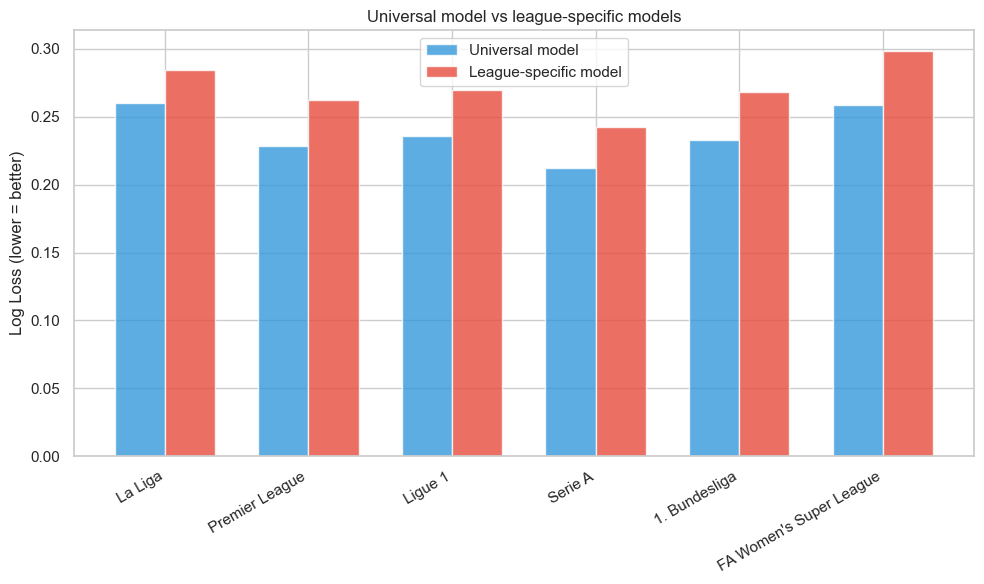

In [9]:
# Visualise universal vs league-specific
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = range(len(lr))
width = 0.35
ax.bar([x - width/2 for x in x_pos], lr["universal_log_loss"], width, label="Universal model", color="#3498db", alpha=0.8)
ax.bar([x + width/2 for x in x_pos], lr["specific_log_loss"], width, label="League-specific model", color="#e74c3c", alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(lr["competition"], rotation=30, ha="right")
ax.set_ylabel("Log Loss (lower = better)")
ax.set_title("Universal model vs league-specific models")
ax.legend()

plt.tight_layout()
plt.show()

---
## 4. Competition difficulty — where do the hardest chances come from?

In [10]:
# Compare average chance quality and conversion efficiency by competition
min_shots = 500
comp_quality = df.groupby("competition").agg(
    shots=("is_goal", "count"),
    actual_goal_rate=("is_goal", "mean"),
    mean_xg=("xg_pred", "mean"),
    mean_sb_xg=("shot_statsbomb_xg", "mean"),
    mean_distance=("distance_to_goal", "mean"),
    mean_defenders=("n_defenders_in_cone", "mean"),
    header_pct=("is_header", "mean"),
    counter_pct=("is_counter_attack", "mean"),
    gender=("gender", "first"),
).query(f"shots >= {min_shots}")

# Conversion efficiency: actual goals / expected goals
comp_quality["conversion_efficiency"] = comp_quality["actual_goal_rate"] / comp_quality["mean_xg"]

print(comp_quality.sort_values("mean_xg", ascending=False)[
    ["shots", "actual_goal_rate", "mean_xg", "conversion_efficiency", "mean_distance", "mean_defenders", "gender"]
].to_string())

                         shots  actual_goal_rate   mean_xg  conversion_efficiency  mean_distance  mean_defenders gender
competition                                                                                                            
African Cup of Nations    1244          0.127814  0.132837               0.962182      18.871276        1.700965    Men
Copa America               790          0.120253  0.128952               0.932539      19.010728        1.655696    Men
NWSL                      1041          0.097983  0.123973               0.790357      17.867678        1.651297  Women
UEFA Women's Euro         1793          0.119353  0.121784               0.980040      17.181714        1.874512  Women
La Liga                  21210          0.125318  0.119832               1.045779      19.114706        1.657520    Men
FIFA World Cup            3904          0.113473  0.117873               0.962673      19.277435        1.719006    Men
UEFA Euro                 2629          

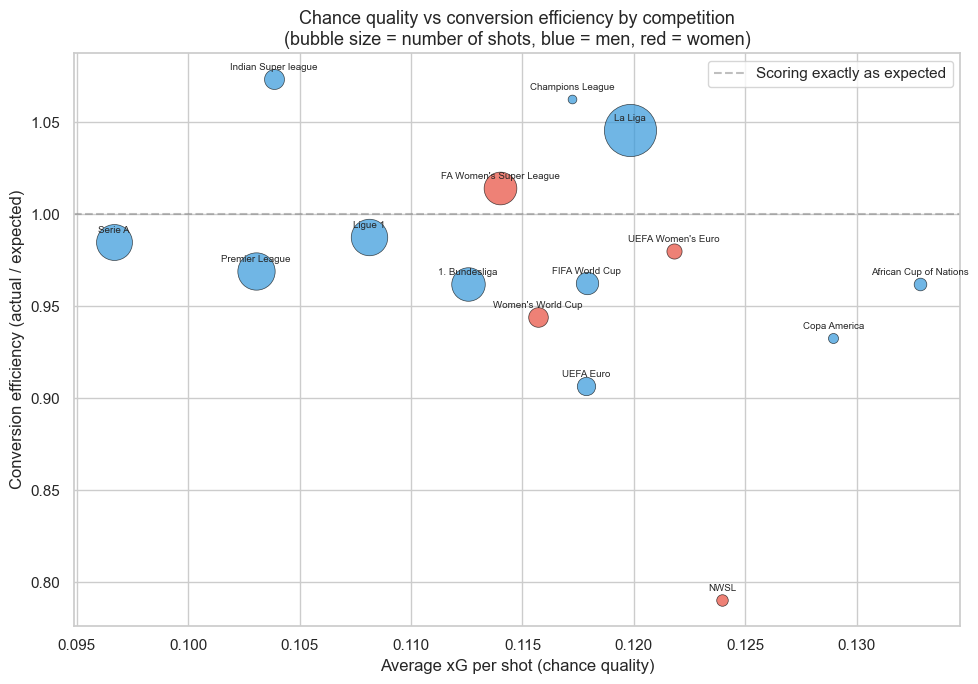

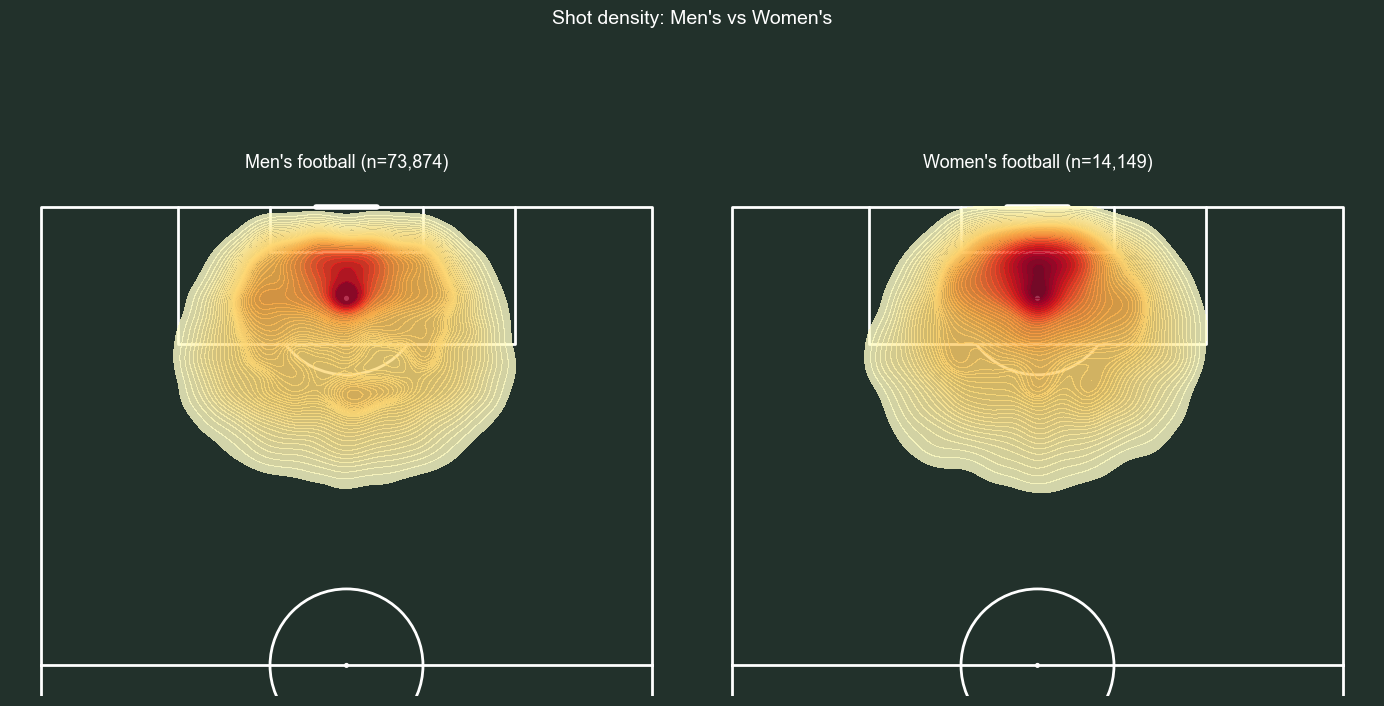

In [11]:
# Scatter: average xG (chance quality) vs conversion efficiency
fig, ax = plt.subplots(figsize=(10, 7))

for _, row in comp_quality.iterrows():
    color = "#e74c3c" if row["gender"] == "Women" else "#3498db"
    ax.scatter(row["mean_xg"], row["conversion_efficiency"], s=row["shots"] / 15, 
               color=color, alpha=0.7, edgecolors="black", linewidth=0.5)
    ax.annotate(row.name, (row["mean_xg"], row["conversion_efficiency"]),
                fontsize=7, ha="center", va="bottom", xytext=(0, 5), textcoords="offset points")

ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="Scoring exactly as expected")
ax.set_xlabel("Average xG per shot (chance quality)", fontsize=12)
ax.set_ylabel("Conversion efficiency (actual / expected)", fontsize=12)
ax.set_title("Chance quality vs conversion efficiency by competition\n(bubble size = number of shots, blue = men, red = women)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

# Shot location heatmaps: men's vs women's
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
pitch = VerticalPitch(pitch_type="statsbomb", half=True, pitch_color="#22312b", line_color="white")

for ax, gender in zip(axes, ["Men", "Women"]):
    group = df[df["gender"] == gender]
    pitch.draw(ax=ax)
    pitch.kdeplot(group["x"], group["y"], ax=ax, fill=True, cmap="YlOrRd", levels=50, alpha=0.8)
    ax.set_title(f"{gender}'s football (n={len(group):,})", color="white", fontsize=13)

fig.set_facecolor("#22312b")
plt.suptitle("Shot density: Men's vs Women's", color="white", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Match-level xG timelines

Pick famous matches and visualise cumulative xG over 90 minutes.

In [12]:
# Find interesting matches (high total xG or big xG difference)
match_stats = df.groupby(["match_id", "competition", "season"]).agg(
    shots=("is_goal", "count"),
    goals=("is_goal", "sum"),
    total_xg=("xg_pred", "sum"),
    teams=("team", lambda x: " vs ".join(x.unique()[:2])),
).sort_values("total_xg", ascending=False).reset_index()

print("Matches with highest total xG:")
print(match_stats.head(15)[["teams", "competition", "shots", "goals", "total_xg"]].to_string(index=False))

Matches with highest total xG:
                                  teams            competition  shots  goals  total_xg
    France Women's vs Australia Women's      Women's World Cup     58     13 17.684538
                      Congo DR vs Egypt African Cup of Nations     41     17 14.839764
      Germany Women's vs France Women's      UEFA Women's Euro     39     13 13.383862
      Sweden Women's vs England Women's      UEFA Women's Euro     45      9 12.560370
                  France vs Switzerland              UEFA Euro     49     15 12.498785
               Congo DR vs South Africa African Cup of Nations     33     11 11.933418
         Atlético Madrid vs Real Madrid       Champions League     53     10 11.500018
               Bayern Munich vs Chelsea       Champions League     59      9 11.346890
                    England vs Colombia         FIFA World Cup     41      9 10.542750
                     Denmark vs Croatia         FIFA World Cup     45      7 10.536824
            

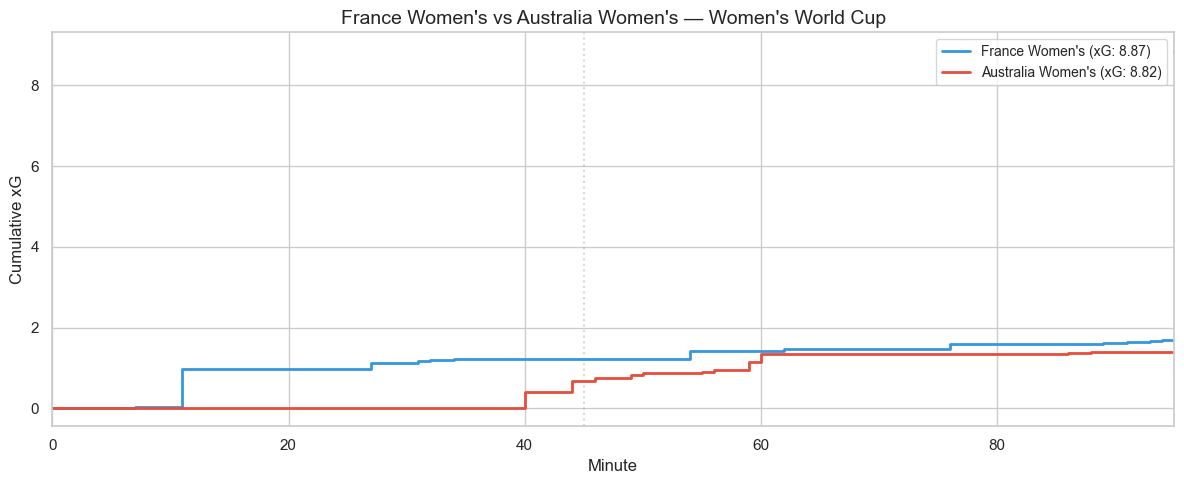

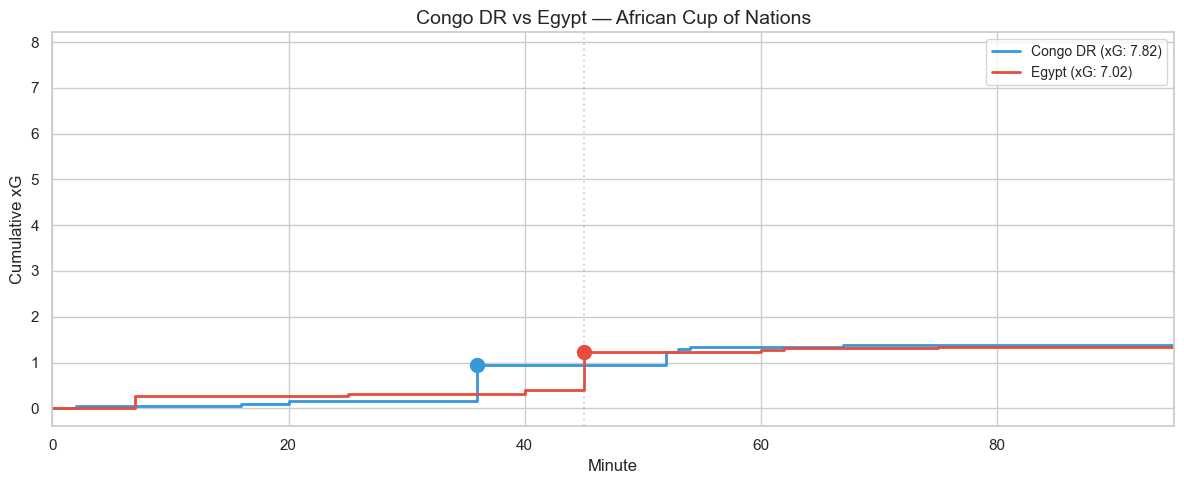

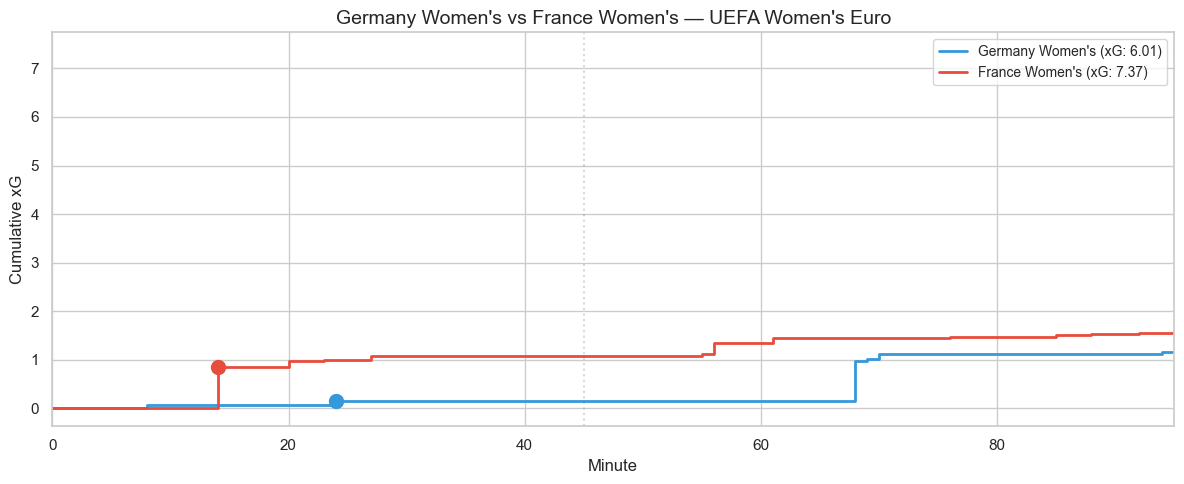

In [13]:
def plot_xg_timeline(match_id, title=None):
    """Plot cumulative xG timeline for a match."""
    match = df[df["match_id"] == match_id].sort_values("minute")
    teams = match["team"].unique()
    if len(teams) < 2:
        return
    
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ["#3498db", "#e74c3c"]
    
    for i, team in enumerate(teams):
        team_shots = match[match["team"] == team].copy()
        team_shots["cum_xg"] = team_shots["xg_pred"].cumsum()
        
        # Step plot for cumulative xG
        minutes = [0] + team_shots["minute"].tolist() + [95]
        xg_vals = [0] + team_shots["cum_xg"].tolist() + [team_shots["cum_xg"].iloc[-1]]
        ax.step(minutes, xg_vals, where="post", color=colors[i], linewidth=2,
                label=f"{team} (xG: {team_shots['xg_pred'].sum():.2f})")
        
        # Mark goals
        goals = team_shots[team_shots["is_goal"] == 1]
        for _, goal in goals.iterrows():
            ax.plot(goal["minute"], goal["cum_xg"], "o", color=colors[i], markersize=10, zorder=5)
    
    actual_score = " - ".join([
        str(match[match["team"] == t]["is_goal"].sum()) for t in teams
    ])
    
    if title is None:
        title = f"{teams[0]} vs {teams[1]} ({actual_score})"
    
    ax.set_xlabel("Minute", fontsize=12)
    ax.set_ylabel("Cumulative xG", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=10)
    ax.set_xlim(0, 95)
    ax.axvline(45, color="gray", linestyle=":", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot the top 3 most interesting matches
for _, row in match_stats.head(3).iterrows():
    plot_xg_timeline(row["match_id"], f"{row['teams']} — {row['competition']}")

---
## 5. Player xG over/underperformers

Now we bring player identity back — not for training, but for analysis. Who consistently beats their xG?

In [14]:
# Non-penalty shots only for fair comparison
non_pen = df[df["is_penalty"] == 0].copy()

player_stats = non_pen.groupby("player").agg(
    shots=("is_goal", "count"),
    goals=("is_goal", "sum"),
    total_xg=("xg_pred", "sum"),
    total_sb_xg=("shot_statsbomb_xg", "sum"),
).query("shots >= 50")

player_stats["goals_minus_xg"] = player_stats["goals"] - player_stats["total_xg"]
player_stats["goal_rate"] = player_stats["goals"] / player_stats["shots"]
player_stats["xg_per_shot"] = player_stats["total_xg"] / player_stats["shots"]

print("=== BIGGEST OVERPERFORMERS (Goals - xG) ===")
print(player_stats.nlargest(15, "goals_minus_xg")[
    ["shots", "goals", "total_xg", "goals_minus_xg", "goal_rate", "xg_per_shot"]
].to_string())

print("\n=== BIGGEST UNDERPERFORMERS ===")
print(player_stats.nsmallest(15, "goals_minus_xg")[
    ["shots", "goals", "total_xg", "goals_minus_xg", "goal_rate", "xg_per_shot"]
].to_string())

=== BIGGEST OVERPERFORMERS (Goals - xG) ===
                                 shots  goals    total_xg  goals_minus_xg  goal_rate  xg_per_shot
player                                                                                           
Lionel Andrés Messi Cuccittini    2587    444  355.039642       88.960358   0.171627     0.137240
Luis Alberto Suárez Díaz           628    132  113.330734       18.669266   0.210191     0.180463
Samuel Eto''o Fils                 299     63   51.149387       11.850613   0.210702     0.171068
Kylian Mbappé Lottin               294     55   44.066200       10.933800   0.187075     0.149885
Gareth Frank Bale                  121     23   14.039973        8.960027   0.190083     0.116033
Ousmane Dembélé                    176     27   18.424015        8.575985   0.153409     0.104682
Ivan Rakitić                       227     27   18.437988        8.562012   0.118943     0.081225
Zlatan Ibrahimović                 224     44   35.970753        8.029247 

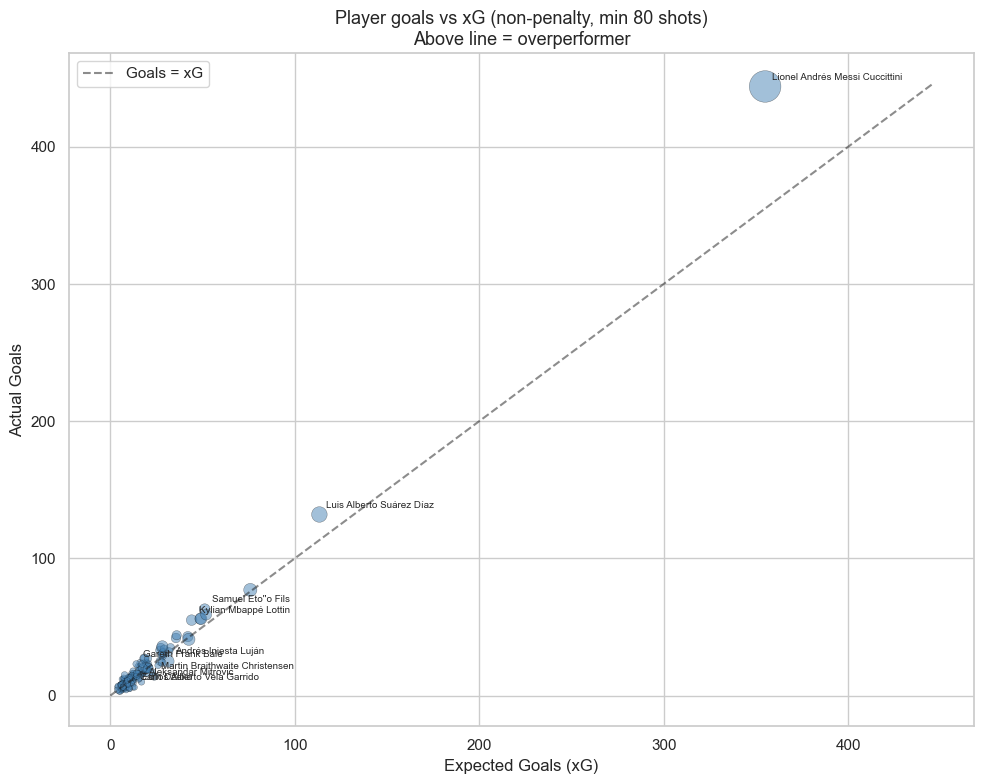

In [15]:
# Scatter plot: xG vs actual goals
fig, ax = plt.subplots(figsize=(10, 8))

ps = player_stats.query("shots >= 80")
ax.scatter(ps["total_xg"], ps["goals"], s=ps["shots"] / 5, alpha=0.5, color="steelblue", edgecolors="black", linewidth=0.3)

# Perfect line
max_val = max(ps["total_xg"].max(), ps["goals"].max()) + 2
ax.plot([0, max_val], [0, max_val], "k--", alpha=0.5, label="Goals = xG")

# Label notable players
top_over = ps.nlargest(5, "goals_minus_xg")
top_under = ps.nsmallest(5, "goals_minus_xg")
for _, row in pd.concat([top_over, top_under]).iterrows():
    ax.annotate(row.name, (row["total_xg"], row["goals"]),
                fontsize=7, ha="left", xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Expected Goals (xG)", fontsize=12)
ax.set_ylabel("Actual Goals", fontsize=12)
ax.set_title("Player goals vs xG (non-penalty, min 80 shots)\nAbove line = overperformer", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Shot map coloured by xG

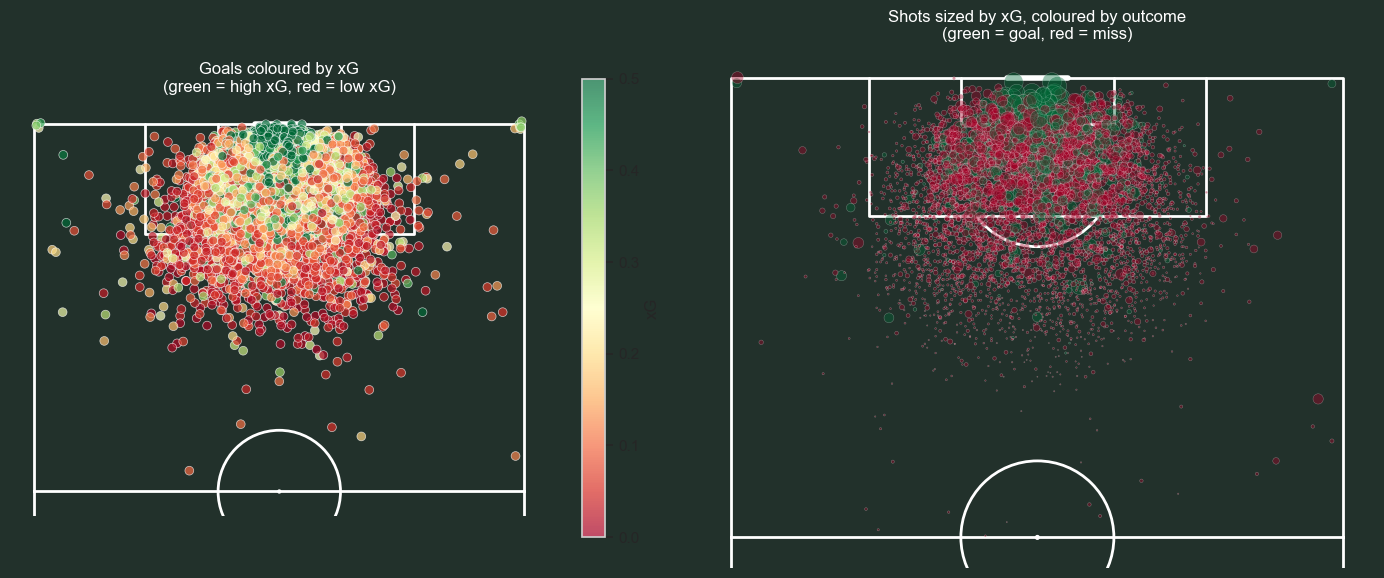

In [16]:
non_pen = df[df["is_penalty"] == 0]

pitch = VerticalPitch(pitch_type="statsbomb", half=True, pitch_color="#22312b", line_color="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Goals coloured by xG
pitch.draw(ax=axes[0])
goals = non_pen[non_pen["is_goal"] == 1]
sc = pitch.scatter(goals["x"], goals["y"], c=goals["xg_pred"], ax=axes[0],
                   s=40, cmap="RdYlGn", vmin=0, vmax=0.5, edgecolors="white", linewidth=0.5, alpha=0.7)
axes[0].set_title("Goals coloured by xG\n(green = high xG, red = low xG)", color="white", fontsize=12)
plt.colorbar(sc, ax=axes[0], shrink=0.6, label="xG")

# All shots sized by xG
pitch.draw(ax=axes[1])
sample = non_pen.sample(5000, random_state=42)
sc2 = pitch.scatter(sample["x"], sample["y"], s=sample["xg_pred"] * 200,
                    c=sample["is_goal"], cmap="RdYlGn", ax=axes[1],
                    edgecolors="white", linewidth=0.3, alpha=0.4)
axes[1].set_title("Shots sized by xG, coloured by outcome\n(green = goal, red = miss)", color="white", fontsize=12)

fig.set_facecolor("#22312b")
plt.tight_layout()
plt.show()

---
## Key takeaways

### Model generalisation
- The universal model generalises well across leagues — calibration is consistent
- League-specific models offer marginal improvement at best, suggesting the physics of shooting is universal

### Men's vs Women's
- Women's football produces chances from slightly closer range and wider angles
- The model calibrates well for both, but subtle differences exist in feature distributions
- Fewer defenders in the cone in women's football suggests different defensive structures

### Competition difficulty
- Top European leagues have the tightest defensive structures (more defenders, longer distances)
- International tournaments produce higher-quality chances on average
- Conversion efficiency varies — some leagues consistently over/underperform their xG

### Player analysis
- Elite finishers consistently outperform their xG — this is the "finishing skill" xG doesn't capture
- The gap between goals and xG is real signal, not noise — it persists across seasons

### Limitations to acknowledge
- The model doesn't account for goalkeeper quality, detailed defensive pressure, or shot placement
- Competition-level differences may partly reflect data quality differences across StatsBomb's coverage
- Small sample sizes for some competitions limit the strength of per-league conclusions